# 02 - Citation source shift extension

This notebook starts the second research question:

> During a PC service year, do a researcher's citations shift toward
> papers from that same conference?

This is related to the main event study analysis, but it is not the
same outcome. The main analysis asks whether papers from the PC
conference cite the researcher more. This notebook asks whether the PC
conference accounts for a larger share of the researcher's citations
from the studied conferences.

## 1. Setup

In [1]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "project_setup.py").exists() and (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError(
        "Could not find the repository root. Launch Jupyter from the repo root "
        "or set PYTHONPATH to the folder containing project_setup.py."
    )

import os
import sys
from datetime import date
from pathlib import Path

os.environ.setdefault("ARROW_USER_SIMD_LEVEL", "NONE")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import IFrame, Markdown, display
from matplotlib import font_manager

from project_setup import ensure_dirs, setup_project

setup = setup_project()
PROJECT = setup.project_folder

STEP_3_PREPARED = PROJECT / "step_3_data" / "prepared"
STEP_4_PREPARED = PROJECT / "step_4_data" / "prepared"
STEP_4_SUMMARY = PROJECT / "step_4_artifacts" / "summary_tables"
CITATION_SHIFT_FIGURES = (
    PROJECT / "step_4_artifacts" / "figures_citation_shift_event_study"
)
REPORT_FIGURES = PROJECT / "report_latex" / "figures"

ensure_dirs(STEP_4_PREPARED, STEP_4_SUMMARY, CITATION_SHIFT_FIGURES, REPORT_FIGURES)

PANEL_PATH = STEP_3_PREPARED / "panel.parquet"
EVENT_ROWS_PATH = STEP_4_PREPARED / "career_age_event_window_rows.parquet"

SOURCE_SHIFT_ROWS_OUT = STEP_4_PREPARED / "citation_source_shift_event_rows.parquet"
SOURCE_SHIFT_EVENT_SUMMARY_OUT = (
    STEP_4_SUMMARY / "citation_source_shift_event_summary.csv"
)
SOURCE_SHIFT_PC_YEAR_SUMMARY_OUT = (
    STEP_4_SUMMARY / "citation_source_shift_pc_year_summary.csv"
)
SOURCE_SHIFT_UNIT_SUMMARY_OUT = (
    STEP_4_SUMMARY / "citation_source_shift_event_unit_summary.csv"
)
SOURCE_SHIFT_SPLIT_EVENT_SUMMARY_OUT = (
    STEP_4_SUMMARY / "source_shift_split_events.csv"
)
SOURCE_SHIFT_SPLIT_PC_YEAR_SUMMARY_OUT = (
    STEP_4_SUMMARY / "source_shift_split_pc_year.csv"
)
SOURCE_SHIFT_FIGURE_OUT = CITATION_SHIFT_FIGURES / "overall.pdf"
SOURCE_SHIFT_BROAD_SERVICE_FIGURE_OUT = (
    CITATION_SHIFT_FIGURES / "no_earlier_broad_service_main_text.pdf"
)
REPORT_SOURCE_SHIFT_BROAD_SERVICE_FIGURE_OUT = (
    REPORT_FIGURES / "citation_source_shift_no_earlier_broad_service.pdf"
)
MAIN_TEXT_CONFERENCE_GROUPS = ["ICFP", "POPL", "PLDI 2021 onward"]

print("Project folder: .")
print(f"Run mode: {setup.run_mode}")
print(f"Overwrite data: {setup.overwrite_data}")
print(f"Overwrite artifacts: {setup.overwrite_artifacts}")
print(f"Run date: {date.today().isoformat()}")

Project folder: .
Run mode: fast
Overwrite data: False
Overwrite artifacts: True
Run date: 2026-06-19


## 2. Plot style

In [2]:
font_path = PROJECT / "fonts" / "LinLibertine_R.ttf"
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    font_prop = font_manager.FontProperties(fname=font_path)
    font_family = font_prop.get_name()
else:
    font_family = "serif"

mpl.rcParams.update(
    {
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "font.size": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "font.family": font_family,
        "text.usetex": True,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

CONFERENCE_COLORS = {
    "All": "black",
    "ICFP": "#f5bde6",
    "OOPSLA": "#8aadf4",
    "PLDI before 2021": "#e5c890",
    "PLDI 2021 onward": "#e5c890",
    "POPL": "#81c8be",
}

## 3. Load the current panel and event windows

For the source shift check, I keep balanced event windows with
exactly one observed PC service year in the same conference. This avoids
mixing the selected PC year with later same conference PC service.

In [3]:
panel = pd.read_parquet(PANEL_PATH)
event_rows = pd.read_parquet(EVENT_ROWS_PATH)
event_rows = event_rows.loc[
    event_rows["is_balanced_window"].eq(True)
    & event_rows["n_pc_years_this_conference"].eq(1)
].copy()

panel["citation_count"] = panel["citation_count"].fillna(0)
event_rows["citation_count"] = event_rows["citation_count"].fillna(0)

print(f"Panel rows: {len(panel):,}")
print(f"Single-service balanced event-window rows: {len(event_rows):,}")
print(f"Event units: {event_rows['event_unit_id'].nunique():,}")
display(event_rows.head())

Panel rows: 37,128
Single-service balanced event-window rows: 1,500
Event units: 300


,panel_row_id,researcher_id,name,conference,year,pc_status,citation_count,mapped_name_for_matching,openalex_id,orcid_from_openalex,...,event_unit_id,is_balanced_window,has_followup_pc_service,is_isolated_first_pc_event_window,log10_citations,baseline_raw_citations,baseline_log10_citations,delta_raw_citations,delta_log10_citations,event_definition
0,abhinavverma1|PLDI|2021,abhinavverma1,Abhinav Verma,PLDI,2021,0,0.0,Abhinav Verma,A5101988843,0000-0002-9820-8285,...,abhinavverma1|PLDI|2023,True,0,True,0.00000,0.0,0.0,0.0,0.00000,balanced_no_followup_pc_t1_t2
1,abhinavverma1|PLDI|2022,abhinavverma1,Abhinav Verma,PLDI,2022,0,0.0,Abhinav Verma,A5101988843,0000-0002-9820-8285,...,abhinavverma1|PLDI|2023,True,0,True,0.00000,0.0,0.0,0.0,0.00000,balanced_no_followup_pc_t1_t2
2,abhinavverma1|PLDI|2023,abhinavverma1,Abhinav Verma,PLDI,2023,1,0.0,Abhinav Verma,A5101988843,0000-0002-9820-8285,...,abhinavverma1|PLDI|2023,True,0,True,0.00000,0.0,0.0,0.0,0.00000,balanced_no_followup_pc_t1_t2
3,abhinavverma1|PLDI|2024,abhinavverma1,Abhinav Verma,PLDI,2024,0,1.0,Abhinav Verma,A5101988843,0000-0002-9820-8285,...,abhinavverma1|PLDI|2023,True,0,True,0.30103,0.0,0.0,1.0,0.30103,balanced_no_followup_pc_t1_t2
4,abhinavverma1|PLDI|2025,abhinavverma1,Abhinav Verma,PLDI,2025,0,0.0,Abhinav Verma,A5101988843,0000-0002-9820-8285,...,abhinavverma1|PLDI|2023,True,0,True,0.00000,0.0,0.0,0.0,0.00000,balanced_no_followup_pc_t1_t2


## 4. Define the citation source share

For each researcher and year, I first add citations across the studied
conferences. Then, for each event conference, I compute the share of the
researcher's yearly citations that came from that conference:

$$
q_{i,c,t} =
\frac{\mathrm{citations}_{i,c,t}}
     {\sum_{c'} \mathrm{citations}_{i,c',t}} .
$$

If the researcher has zero citations from all studied conferences in a
year, the share is undefined. I keep those rows in the data and mark the
share as missing rather than forcing it to zero.

In [4]:
researcher_year_totals = (
    panel.groupby(["researcher_id", "year"], as_index=False)
    .agg(total_studied_conference_citations=("citation_count", "sum"))
)

source_rows = event_rows.merge(
    researcher_year_totals,
    on=["researcher_id", "year"],
    how="left",
    validate="many_to_one",
)

source_rows["source_share"] = np.where(
    source_rows["total_studied_conference_citations"].gt(0),
    source_rows["citation_count"]
    / source_rows["total_studied_conference_citations"],
    np.nan,
)

event_pc_year = (
    source_rows.loc[source_rows["event_time"].eq(0), ["event_unit_id", "year"]]
    .rename(columns={"year": "pc_year"})
    .drop_duplicates()
)
source_rows = source_rows.merge(
    event_pc_year, on="event_unit_id", how="left", validate="many_to_one"
)

source_rows["analysis_conference"] = source_rows["conference"]
source_rows.loc[
    source_rows["conference"].eq("PLDI") & source_rows["pc_year"].lt(2021),
    "analysis_conference",
] = "PLDI before 2021"
source_rows.loc[
    source_rows["conference"].eq("PLDI") & source_rows["pc_year"].ge(2021),
    "analysis_conference",
] = "PLDI 2021 onward"

reference_baseline = (
    source_rows.loc[source_rows["event_time"].eq(-2)]
    .groupby("event_unit_id", as_index=False)
    .agg(
        baseline_source_share=("source_share", "first"),
        baseline_defined_years=("source_share", "count"),
        baseline_total_citations=(
            "total_studied_conference_citations",
            "first",
        ),
    )
)

source_rows = source_rows.merge(
    reference_baseline, on="event_unit_id", how="left", validate="many_to_one"
)
source_rows["delta_source_share"] = (
    source_rows["source_share"] - source_rows["baseline_source_share"]
)
source_rows["source_share_pct"] = 100 * source_rows["source_share"]
source_rows["delta_source_share_pp"] = 100 * source_rows["delta_source_share"]

cols = [
    "event_unit_id",
    "researcher_id",
    "name",
    "conference",
    "analysis_conference",
    "pc_year",
    "year",
    "event_time",
    "pc_status",
    "citation_count",
    "total_studied_conference_citations",
    "source_share",
    "baseline_source_share",
    "delta_source_share",
    "baseline_defined_years",
]
display(source_rows[cols].head(10))

,event_unit_id,researcher_id,name,conference,analysis_conference,pc_year,year,event_time,pc_status,citation_count,total_studied_conference_citations,source_share,baseline_source_share,delta_source_share,baseline_defined_years
0,abhinavverma1|PLDI|2023,abhinavverma1,Abhinav Verma,PLDI,PLDI 2021 onward,2023,2021,-2,0,0.0,0.0,NaN,NaN,NaN,0
1,abhinavverma1|PLDI|2023,abhinavverma1,Abhinav Verma,PLDI,PLDI 2021 onward,2023,2022,-1,0,0.0,0.0,NaN,NaN,NaN,0
2,abhinavverma1|PLDI|2023,abhinavverma1,Abhinav Verma,PLDI,PLDI 2021 onward,2023,2023,0,1,0.0,0.0,NaN,NaN,NaN,0
3,abhinavverma1|PLDI|2023,abhinavverma1,Abhinav Verma,PLDI,PLDI 2021 onward,2023,2024,1,0,1.0,1.0,1.000000,NaN,NaN,0
4,abhinavverma1|PLDI|2023,abhinavverma1,Abhinav Verma,PLDI,PLDI 2021 onward,2023,2025,2,0,0.0,0.0,NaN,NaN,NaN,0
5,adriansampson|PLDI|2020,adriansampson,Adrian Sampson,PLDI,PLDI before 2021,2020,2018,-2,0,1.0,4.0,0.250000,0.25,0.000000,1
6,adriansampson|PLDI|2020,adriansampson,Adrian Sampson,PLDI,PLDI before 2021,2020,2019,-1,0,1.0,14.0,0.071429,0.25,-0.178571,1
7,adriansampson|PLDI|2020,adriansampson,Adrian Sampson,PLDI,PLDI before 2021,2020,2020,0,1,0.0,6.0,0.000000,0.25,-0.250000,1
8,adriansampson|PLDI|2020,adriansampson,Adrian Sampson,PLDI,PLDI before 2021,2020,2021,1,0,2.0,4.0,0.500000,0.25,0.250000,1
9,adriansampson|PLDI|2020,adriansampson,Adrian Sampson,PLDI,PLDI before 2021,2020,2022,2,0,2.0,6.0,0.333333,0.25,0.083333,1


## 5. PC year source shift summary

In [5]:
def summarize_pc_year(frame, group_name):
    pc = frame.loc[frame["event_time"].eq(0)].copy()
    defined_delta = pc["delta_source_share"].notna()
    defined_share = pc["source_share"].notna()
    return {
        "group": group_name,
        "event_units": pc["event_unit_id"].nunique(),
        "defined_pc_year_shares": int(defined_share.sum()),
        "defined_pc_year_deltas": int(defined_delta.sum()),
        "zero_total_citation_pc_years": int(
            pc["total_studied_conference_citations"].eq(0).sum()
        ),
        "mean_pc_year_share_pct": 100 * pc["source_share"].mean(),
        "median_pc_year_share_pct": 100 * pc["source_share"].median(),
        "mean_baseline_share_pct": 100 * pc["baseline_source_share"].mean(),
        "mean_delta_source_share_pp": 100 * pc["delta_source_share"].mean(),
        "median_delta_source_share_pp": 100 * pc["delta_source_share"].median(),
    }


pc_year_summary_rows = [summarize_pc_year(source_rows, "All")]
for group, frame in source_rows.groupby("analysis_conference", sort=True):
    pc_year_summary_rows.append(summarize_pc_year(frame, group))

pc_year_summary = pd.DataFrame(pc_year_summary_rows)
numeric_cols = pc_year_summary.select_dtypes(include=[np.number]).columns
pc_year_summary[numeric_cols] = pc_year_summary[numeric_cols].round(3)
display(pc_year_summary)

,group,event_units,defined_pc_year_shares,defined_pc_year_deltas,zero_total_citation_pc_years,mean_pc_year_share_pct,median_pc_year_share_pct,mean_baseline_share_pct,mean_delta_source_share_pp,median_delta_source_share_pp
0,All,300,275,253,25,35.276,30.588,33.589,1.777,0.000
1,ICFP,85,81,72,4,30.068,25.000,32.663,-1.155,0.000
2,OOPSLA,21,20,19,1,42.434,47.581,45.151,-2.860,-15.359
3,PLDI 2021 onward,84,67,60,17,38.986,35.714,34.692,4.245,7.897
4,PLDI before 2021,16,14,14,2,26.513,19.643,28.997,-3.364,-11.968
5,POPL,94,93,88,1,36.919,33.333,31.693,4.312,0.000


## 6. Event time summary with bootstrap intervals

In [6]:
EVENT_TIMES = [-2, -1, 0, 1, 2]
RNG_SEED = 1234
BOOTSTRAP_REPS = 2000


def bootstrap_mean_ci(frame, value_col, unit_col="event_unit_id", n_boot=BOOTSTRAP_REPS):
    value_by_unit = (
        frame[[unit_col, value_col]]
        .drop_duplicates(subset=[unit_col])
        .set_index(unit_col)[value_col]
    )
    unit_ids = value_by_unit.index.to_numpy()
    if len(unit_ids) == 0:
        return np.nan, np.nan, np.nan

    values = value_by_unit.dropna()
    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(RNG_SEED)
    boot_means = []
    for _ in range(n_boot):
        sampled_ids = rng.choice(unit_ids, size=len(unit_ids), replace=True)
        sampled_values = value_by_unit.reindex(sampled_ids).dropna()
        if len(sampled_values) > 0:
            boot_means.append(sampled_values.mean())

    if not boot_means:
        return values.mean(), np.nan, np.nan

    return (
        values.mean(),
        np.percentile(boot_means, 2.5),
        np.percentile(boot_means, 97.5),
    )


def summarize_event_time(frame, group_name):
    rows = []
    for event_time in EVENT_TIMES:
        t_frame = frame.loc[frame["event_time"].eq(event_time)].copy()
        mean_delta, ci_low, ci_high = bootstrap_mean_ci(
            t_frame, "delta_source_share"
        )
        mean_share, share_ci_low, share_ci_high = bootstrap_mean_ci(
            t_frame, "source_share"
        )
        rows.append(
            {
                "group": group_name,
                "event_time": event_time,
                "event_units": t_frame["event_unit_id"].nunique(),
                "defined_source_shares": int(t_frame["source_share"].notna().sum()),
                "defined_delta_shares": int(
                    t_frame["delta_source_share"].notna().sum()
                ),
                "zero_total_citation_years": int(
                    t_frame["total_studied_conference_citations"].eq(0).sum()
                ),
                "mean_source_share_pct": 100 * mean_share,
                "source_share_ci_low_pct": 100 * share_ci_low,
                "source_share_ci_high_pct": 100 * share_ci_high,
                "mean_delta_source_share_pp": 100 * mean_delta,
                "delta_ci_low_pp": 100 * ci_low,
                "delta_ci_high_pp": 100 * ci_high,
            }
        )
    return rows


summary_rows = summarize_event_time(
    source_rows.loc[
        source_rows["analysis_conference"].isin(MAIN_TEXT_CONFERENCE_GROUPS)
    ].copy(),
    "All",
)
for group, frame in source_rows.groupby("analysis_conference", sort=True):
    summary_rows.extend(summarize_event_time(frame, group))

event_summary = pd.DataFrame(summary_rows)
numeric_cols = event_summary.select_dtypes(include=[np.number]).columns
event_summary[numeric_cols] = event_summary[numeric_cols].round(3)
display(event_summary)

,group,event_time,event_units,defined_source_shares,defined_delta_shares,zero_total_citation_years,mean_source_share_pct,source_share_ci_low_pct,source_share_ci_high_pct,mean_delta_source_share_pp,delta_ci_low_pp,delta_ci_high_pp
0,All,-2,263,231,231,32,32.886,29.307,36.806,0.000,0.000,0.000
1,All,-1,263,239,221,24,32.532,28.898,36.209,-1.612,-6.418,2.820
2,All,0,263,241,220,22,35.191,31.765,38.644,2.504,-2.240,6.975
3,All,1,263,248,222,15,32.656,29.051,36.310,-0.480,-5.243,4.253
4,All,2,263,252,226,11,26.389,23.409,29.442,-5.307,-9.538,-0.585
5,ICFP,-2,85,74,74,11,32.663,25.404,40.564,0.000,0.000,0.000
6,ICFP,-1,85,76,68,9,28.473,21.560,35.048,-5.245,-14.072,3.980
7,ICFP,0,85,81,72,4,30.068,25.173,35.885,-1.155,-10.538,7.516
8,ICFP,1,85,78,69,7,27.425,21.144,34.017,-4.468,-12.518,3.689
9,ICFP,2,85,84,74,1,21.352,16.330,26.434,-11.852,-20.884,-3.645


## 7. Split summaries

I now repeat the source shift check with the same split logic used
for the balanced event study figures:

- all isolated balanced event units,
- event units with no earlier main PC evidence,
- event units with no earlier service, meaning no earlier
  same conference broad service evidence in the available checks,
- career age splits inside each of those samples.

I create fixed career age buckets (0--9, 10--19, and 20+ years).

In [7]:
def broad_first_service_mask(frame):
    return frame["is_true_first_broad_service_in_observed_year_conf"].eq(True)


sample_definitions = [
    {
        "sample_key": "all_balanced_event_units",
        "sample_label": "All isolated balanced event units",
        "selector": lambda frame: frame,
    },
    {
        "sample_key": "no_earlier_main_pc_evidence",
        "sample_label": "No earlier main-PC evidence found",
        "selector": lambda frame: frame.loc[
            frame["source_history_pc_group_this_conference"].eq(
                "source_verified_first_pc_year"
            )
        ],
    },
    {
        "sample_key": "no_earlier_broad_service_evidence",
        "sample_label": "No earlier service",
        "selector": lambda frame: frame.loc[broad_first_service_mask(frame)],
    },
]


def cohort_frames(sample_rows, split_kind):
    sample_units = sample_rows.drop_duplicates("event_unit_id")
    median_career_age = sample_units["career_age_at_first_pc"].median()
    if split_kind != "fixed_buckets":
        raise ValueError(f"Unknown split_kind: {split_kind}")

    career_age = sample_rows["career_age_at_first_pc"]
    return [
        ("all_in_sample", "All in sample", sample_rows, median_career_age),
        (
            "career_age_0_9",
            "Career age 0-9 years",
            sample_rows.loc[career_age.lt(10)],
            median_career_age,
        ),
        (
            "career_age_10_19",
            "Career age 10-19 years",
            sample_rows.loc[career_age.ge(10) & career_age.lt(20)],
            median_career_age,
        ),
        (
            "career_age_20_plus",
            "Career age 20+ years",
            sample_rows.loc[career_age.ge(20)],
            median_career_age,
        ),
    ]


def summarize_split_event_time(frame, analysis_group, sample, split_kind, cohort):
    sample_key, sample_label = sample["sample_key"], sample["sample_label"]
    cohort_key, cohort_label, cohort_rows, median_career_age = cohort
    rows = []
    for event_time in EVENT_TIMES:
        t_frame = cohort_rows.loc[cohort_rows["event_time"].eq(event_time)].copy()
        mean_delta, ci_low, ci_high = bootstrap_mean_ci(
            t_frame, "delta_source_share"
        )
        rows.append(
            {
                "analysis_group": analysis_group,
                "sample_key": sample_key,
                "sample_label": sample_label,
                "split_kind": split_kind,
                "cohort_key": cohort_key,
                "cohort_label": cohort_label,
                "event_time": event_time,
                "event_units": t_frame["event_unit_id"].nunique(),
                "defined_delta_shares": int(
                    t_frame["delta_source_share"].notna().sum()
                ),
                "zero_total_citation_years": int(
                    t_frame["total_studied_conference_citations"].eq(0).sum()
                ),
                "median_career_age_in_sample": median_career_age,
                "mean_delta_source_share_pp": 100 * mean_delta,
                "delta_ci_low_pp": 100 * ci_low,
                "delta_ci_high_pp": 100 * ci_high,
            }
        )
    return rows


def summarize_split_pc_year(frame, analysis_group, sample, split_kind, cohort):
    sample_key, sample_label = sample["sample_key"], sample["sample_label"]
    cohort_key, cohort_label, cohort_rows, median_career_age = cohort
    pc = cohort_rows.loc[cohort_rows["event_time"].eq(0)].copy()
    return {
        "analysis_group": analysis_group,
        "sample_key": sample_key,
        "sample_label": sample_label,
        "split_kind": split_kind,
        "cohort_key": cohort_key,
        "cohort_label": cohort_label,
        "event_units": pc["event_unit_id"].nunique(),
        "defined_pc_year_deltas": int(pc["delta_source_share"].notna().sum()),
        "zero_total_citation_pc_years": int(
            pc["total_studied_conference_citations"].eq(0).sum()
        ),
        "median_career_age_in_sample": median_career_age,
        "mean_pc_year_share_pct": 100 * pc["source_share"].mean(),
        "mean_baseline_share_pct": 100 * pc["baseline_source_share"].mean(),
        "mean_delta_source_share_pp": 100 * pc["delta_source_share"].mean(),
        "median_delta_source_share_pp": 100 * pc["delta_source_share"].median(),
    }


analysis_groups = ["All"] + sorted(source_rows["analysis_conference"].unique())
split_event_rows = []
split_pc_year_rows = []

for analysis_group in analysis_groups:
    if analysis_group == "All":
        analysis_rows = source_rows.loc[
            source_rows["analysis_conference"].isin(MAIN_TEXT_CONFERENCE_GROUPS)
        ].copy()
    else:
        analysis_rows = source_rows.loc[
            source_rows["analysis_conference"].eq(analysis_group)
        ].copy()

    for sample in sample_definitions:
        sample_rows = sample["selector"](analysis_rows).copy()
        for split_kind in ["fixed_buckets"]:
            for cohort in cohort_frames(sample_rows, split_kind):
                split_event_rows.extend(
                    summarize_split_event_time(
                        sample_rows, analysis_group, sample, split_kind, cohort
                    )
                )
                split_pc_year_rows.append(
                    summarize_split_pc_year(
                        sample_rows, analysis_group, sample, split_kind, cohort
                    )
                )

split_event_summary = pd.DataFrame(split_event_rows)
split_pc_year_summary = pd.DataFrame(split_pc_year_rows)

for frame in [split_event_summary, split_pc_year_summary]:
    numeric_cols = frame.select_dtypes(include=[np.number]).columns
    frame[numeric_cols] = frame[numeric_cols].round(3)

display(
    split_pc_year_summary.loc[
        split_pc_year_summary["split_kind"].eq("fixed_buckets")
        & split_pc_year_summary["cohort_key"].eq("all_in_sample"),
        [
            "analysis_group",
            "sample_label",
            "event_units",
            "defined_pc_year_deltas",
            "mean_delta_source_share_pp",
            "median_delta_source_share_pp",
        ],
    ]
)

,analysis_group,sample_label,event_units,defined_pc_year_deltas,mean_delta_source_share_pp,median_delta_source_share_pp
0,All,All isolated balanced event units,263,220,2.504,2.429
4,All,No earlier main-PC evidence found,193,155,4.866,7.143
8,All,No earlier service,87,62,9.196,12.031
12,ICFP,All isolated balanced event units,85,72,-1.155,0.000
16,ICFP,No earlier main-PC evidence found,63,51,3.548,7.692
20,ICFP,No earlier service,26,18,6.628,2.273
24,OOPSLA,All isolated balanced event units,21,19,-2.860,-15.359
28,OOPSLA,No earlier main-PC evidence found,13,11,-6.420,-24.749
32,OOPSLA,No earlier service,6,6,-4.524,-11.993
36,PLDI 2021 onward,All isolated balanced event units,84,60,4.245,7.897


## 8. Event unit check table

In [8]:
unit_summary = (
    source_rows.sort_values(["event_unit_id", "event_time"])
    .groupby("event_unit_id", as_index=False)
    .agg(
        researcher_id=("researcher_id", "first"),
        name=("name", "first"),
        conference=("conference", "first"),
        analysis_conference=("analysis_conference", "first"),
        pc_year=("pc_year", "first"),
        baseline_source_share=("baseline_source_share", "first"),
        baseline_defined_years=("baseline_defined_years", "first"),
        pc_year_source_share=(
            "source_share",
            lambda values: values.iloc[2] if len(values) >= 3 else np.nan,
        ),
        pc_year_delta_source_share=(
            "delta_source_share",
            lambda values: values.iloc[2] if len(values) >= 3 else np.nan,
        ),
        pc_year_citations=(
            "citation_count",
            lambda values: values.iloc[2] if len(values) >= 3 else np.nan,
        ),
        pc_year_total_studied_citations=(
            "total_studied_conference_citations",
            lambda values: values.iloc[2] if len(values) >= 3 else np.nan,
        ),
    )
)
unit_summary["pc_year_source_share_pct"] = (
    100 * unit_summary["pc_year_source_share"]
)
unit_summary["pc_year_delta_source_share_pp"] = (
    100 * unit_summary["pc_year_delta_source_share"]
)

display(
    unit_summary.sort_values("pc_year_delta_source_share_pp", ascending=False)
    .head(15)
)

,event_unit_id,researcher_id,name,conference,analysis_conference,pc_year,baseline_source_share,baseline_defined_years,pc_year_source_share,pc_year_delta_source_share,pc_year_citations,pc_year_total_studied_citations,pc_year_source_share_pct,pc_year_delta_source_share_pp
134,koheisuenaga|POPL|2022,koheisuenaga,Kohei Suenaga,POPL,POPL,2022,0.000000,1,1.000000,1.000000,1.0,1.0,100.000000,100.000000
68,dylanmcdermott1|ICFP|2023,dylanmcdermott1,Dylan McDermott,ICFP,ICFP,2023,0.000000,1,1.000000,1.000000,3.0,3.0,100.000000,100.000000
196,owolabilegunsen|PLDI|2023,owolabilegunsen,Owolabi Legunsen,PLDI,PLDI 2021 onward,2023,0.000000,1,1.000000,1.000000,2.0,2.0,100.000000,100.000000
110,jennifersartor|PLDI|2019,jennifersartor,Jennifer B. Sartor,PLDI,PLDI before 2021,2019,0.000000,1,0.857143,0.857143,6.0,7.0,85.714286,85.714286
255,stephaniebalzer|ICFP|2021,stephaniebalzer,Stephanie Balzer,ICFP,ICFP,2021,0.000000,1,0.833333,0.833333,5.0,6.0,83.333333,83.333333
241,seantreichler|PLDI|2022,seantreichler,Sean Treichler,PLDI,PLDI 2021 onward,2022,0.000000,1,0.750000,0.750000,3.0,4.0,75.000000,75.000000
61,davidiaugust|PLDI|2021,davidiaugust,David I. August,PLDI,PLDI 2021 onward,2021,0.250000,1,1.000000,0.750000,3.0,3.0,100.000000,75.000000
117,jonathansterling|POPL|2023,jonathansterling,Jonathan Sterling,POPL,POPL,2023,0.000000,1,0.750000,0.750000,3.0,4.0,75.000000,75.000000
107,janmidtgaard|ICFP|2023,janmidtgaard,Jan Midtgaard,ICFP,ICFP,2023,0.000000,1,0.714286,0.714286,5.0,7.0,71.428571,71.428571
34,betaziliani|POPL|2020,betaziliani,Beta Ziliani,POPL,POPL,2020,0.285714,1,1.000000,0.714286,3.0,3.0,100.000000,71.428571


## 9. Plot the source share event check

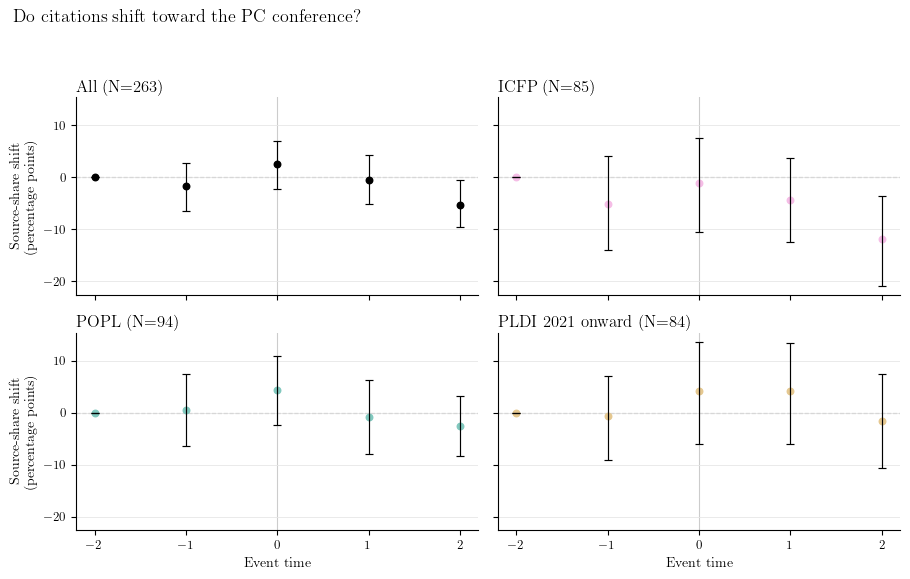

step_4_artifacts/figures_citation_shift_event_study/overall.pdf


In [9]:
plot_groups = ["All", *MAIN_TEXT_CONFERENCE_GROUPS]
plot_data = event_summary.loc[event_summary["group"].isin(plot_groups)].copy()

fig, axes = plt.subplots(2, 2, figsize=(9.2, 5.8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, group in zip(axes, plot_groups):
    g = plot_data.loc[plot_data["group"].eq(group)].sort_values("event_time")
    color = CONFERENCE_COLORS.get(group, "black")
    ax.axhline(0, color="0.55", linewidth=0.8, linestyle="--", zorder=0)
    ax.axvline(0, color="0.80", linewidth=0.8, zorder=0)
    ax.scatter(
        g["event_time"],
        g["mean_delta_source_share_pp"],
        marker="o",
        s=22,
        color=color,
        zorder=3,
    )
    yerr = np.vstack(
        [
            g["mean_delta_source_share_pp"].to_numpy(dtype=float)
            - g["delta_ci_low_pp"].to_numpy(dtype=float),
            g["delta_ci_high_pp"].to_numpy(dtype=float)
            - g["mean_delta_source_share_pp"].to_numpy(dtype=float),
        ]
    )
    ax.errorbar(
        g["event_time"],
        g["mean_delta_source_share_pp"],
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.85,
        capsize=3.0,
        capthick=0.85,
        zorder=4,
    )
    n_units = int(g["event_units"].max()) if len(g) else 0
    ax.set_title(f"{group} (N={n_units})", loc="left", pad=4)
    ax.set_xticks(EVENT_TIMES)
    ax.grid(axis="y", color="0.90", linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[2:]:
    ax.set_xlabel("Event time")
for ax in axes[::2]:
    ax.set_ylabel("Source-share shift\n(percentage points)")

fig.suptitle(
    "Do citations shift toward the PC conference?",
    x=0.02,
    y=0.99,
    ha="left",
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(SOURCE_SHIFT_FIGURE_OUT, bbox_inches="tight")
plt.show()

print(SOURCE_SHIFT_FIGURE_OUT.relative_to(PROJECT))

## 10. Main text source shift comparison figure

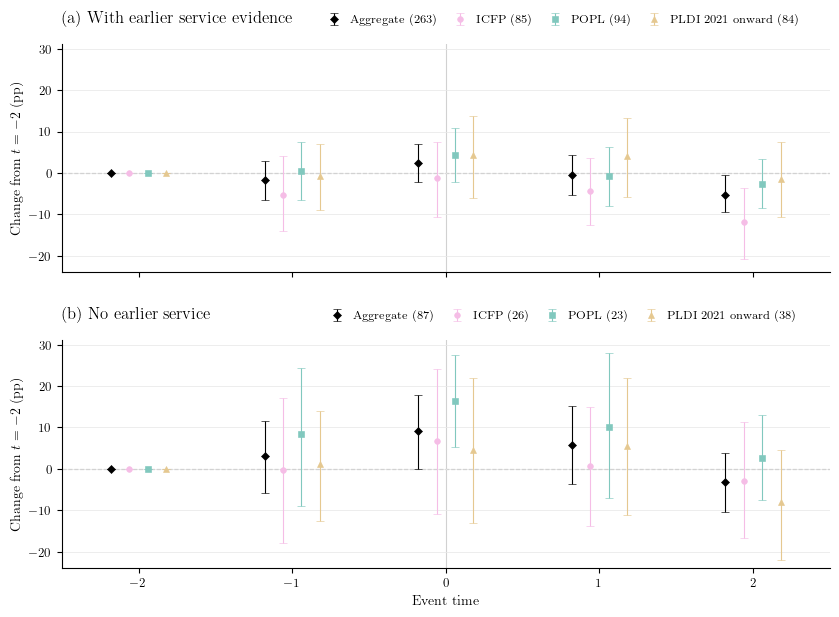

step_4_artifacts/figures_citation_shift_event_study/no_earlier_broad_service_main_text.pdf
report_latex/figures/citation_source_shift_no_earlier_broad_service.pdf


,sample,group,event_units,defined_delta_shares,mean_delta_source_share_pp,delta_ci_low_pp,delta_ci_high_pp
2,With earlier service evidence,Aggregate,263,220,2.504,-2.240,6.975
7,With earlier service evidence,ICFP,85,72,-1.155,-10.538,7.516
12,With earlier service evidence,POPL,94,88,4.312,-2.277,10.870
17,With earlier service evidence,PLDI 2021 onward,84,60,4.245,-5.970,13.693
22,No earlier service,Aggregate,87,62,9.196,0.070,17.935
27,No earlier service,ICFP,26,18,6.628,-10.916,24.005
32,No earlier service,POPL,23,21,16.350,5.351,27.532
37,No earlier service,PLDI 2021 onward,38,23,4.673,-13.154,21.891


In [10]:
main_text_conference_groups = MAIN_TEXT_CONFERENCE_GROUPS.copy()
main_text_all_service_rows = source_rows.loc[
    source_rows["analysis_conference"].isin(main_text_conference_groups)
].copy()
main_text_no_broad_service_rows = source_rows.loc[
    broad_first_service_mask(source_rows)
    & source_rows["analysis_conference"].isin(main_text_conference_groups)
].copy()


def build_main_text_summary(frame):
    rows = summarize_event_time(frame, "Aggregate")
    for group in main_text_conference_groups:
        group_rows = frame.loc[frame["analysis_conference"].eq(group)]
        rows.extend(summarize_event_time(group_rows, group))
    summary = pd.DataFrame(rows)
    numeric_cols = summary.select_dtypes(include=[np.number]).columns
    summary[numeric_cols] = summary[numeric_cols].round(3)
    return summary


main_text_all_service = build_main_text_summary(main_text_all_service_rows)
main_text_no_broad_service = build_main_text_summary(main_text_no_broad_service_rows)

fig, axes = plt.subplots(2, 1, figsize=(8.6, 6.4), sharex=True)
plot_order = ["Aggregate", "ICFP", "POPL", "PLDI 2021 onward"]
offsets = {
    "Aggregate": -0.18,
    "ICFP": -0.06,
    "POPL": 0.06,
    "PLDI 2021 onward": 0.18,
}
markers = {
    "Aggregate": "D",
    "ICFP": "o",
    "POPL": "s",
    "PLDI 2021 onward": "^",
}
display_labels = {
    "Aggregate": "Aggregate",
    "ICFP": "ICFP",
    "POPL": "POPL",
    "PLDI 2021 onward": "PLDI 2021 onward",
}

def draw_source_shift_panel(ax, summary, title, show_legend=False):
    ax.axhline(0, color="0.55", linewidth=0.8, linestyle="--", zorder=0)
    ax.axvline(0, color="0.82", linewidth=0.8, zorder=0)

    for group in plot_order:
        g = (
            summary.loc[summary["group"].eq(group)]
            .sort_values("event_time")
            .copy()
        )
        color = CONFERENCE_COLORS.get(group, "black")
        x = g["event_time"].to_numpy(dtype=float) + offsets[group]
        yerr = np.vstack(
            [
                g["mean_delta_source_share_pp"].to_numpy(dtype=float)
                - g["delta_ci_low_pp"].to_numpy(dtype=float),
                g["delta_ci_high_pp"].to_numpy(dtype=float)
                - g["mean_delta_source_share_pp"].to_numpy(dtype=float),
            ]
        )
        ax.errorbar(
            x,
            g["mean_delta_source_share_pp"],
            yerr=yerr,
            fmt=markers[group],
            markersize=4.1,
            markerfacecolor=color,
            markeredgecolor="black" if group == "Aggregate" else color,
            markeredgewidth=0.45,
            color=color,
            ecolor=color,
            elinewidth=0.8,
            capsize=2.7,
            capthick=0.8,
            zorder=4 if group == "Aggregate" else 3,
            label=f"{display_labels[group]} ({int(g['event_units'].max())})",
        )

    ax.set_title(title, loc="left", pad=16, fontsize=12)
    ax.set_ylabel("Change from $t=-2$ (pp)")
    ax.set_xticks(EVENT_TIMES)
    ax.set_xlim(min(EVENT_TIMES) - 0.5, max(EVENT_TIMES) + 0.5)
    ax.set_ylim(-24, 31)
    ax.grid(axis="y", color="0.91", linewidth=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if show_legend:
        ax.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.65, 1.18),
            ncol=4,
            columnspacing=0.9,
            handletextpad=0.35,
            fontsize=8.5,
        )


draw_source_shift_panel(
    axes[0],
    main_text_all_service,
    "(a) With earlier service evidence",
    show_legend=True,
)
draw_source_shift_panel(
    axes[1],
    main_text_no_broad_service,
    "(b) No earlier service",
    show_legend=True,
)
axes[1].set_xlabel("Event time")
fig.tight_layout(rect=[0, 0, 1, 0.98], h_pad=2.05)
fig.savefig(SOURCE_SHIFT_BROAD_SERVICE_FIGURE_OUT, bbox_inches="tight")
fig.savefig(REPORT_SOURCE_SHIFT_BROAD_SERVICE_FIGURE_OUT, bbox_inches="tight")
plt.show()

for path in [SOURCE_SHIFT_BROAD_SERVICE_FIGURE_OUT, REPORT_SOURCE_SHIFT_BROAD_SERVICE_FIGURE_OUT]:
    print(path.relative_to(PROJECT))

display(
    pd.concat(
        [
            main_text_all_service.assign(sample="With earlier service evidence"),
            main_text_no_broad_service.assign(sample="No earlier service"),
        ],
        ignore_index=True,
    )
    .loc[lambda df: df["event_time"].eq(0), [
        "sample",
        "group",
        "event_units",
        "defined_delta_shares",
        "mean_delta_source_share_pp",
        "delta_ci_low_pp",
        "delta_ci_high_pp",
    ]]
)

## 11. Plot the split checks

In [11]:
def slugify(value):
    return (
        value.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
    )


def plot_split_check(analysis_group, split_kind, output_path):
    page_rows = split_event_summary.loc[
        split_event_summary["analysis_group"].eq(analysis_group)
        & split_event_summary["split_kind"].eq(split_kind)
    ].copy()

    if split_kind != "fixed_buckets":
        raise ValueError(split_kind)
    cohort_order = [
        ("all_in_sample", "All"),
        ("career_age_0_9", "0-9 years"),
        ("career_age_10_19", "10-19 years"),
        ("career_age_20_plus", "20+ years"),
    ]

    sample_order = [
        ("all_balanced_event_units", "All isolated\nbalanced units"),
        ("no_earlier_main_pc_evidence", "No earlier\nmain-PC evidence"),
        ("no_earlier_broad_service_evidence", "No earlier\nservice"),
    ]

    fig, axes = plt.subplots(
        len(sample_order),
        len(cohort_order),
        figsize=(2.55 * len(cohort_order), 6.8),
        sharex=True,
        sharey=True,
    )
    if len(cohort_order) == 1:
        axes = np.array(axes).reshape(len(sample_order), 1)

    for row_idx, (sample_key, sample_label) in enumerate(sample_order):
        for col_idx, (cohort_key, cohort_label) in enumerate(cohort_order):
            ax = axes[row_idx, col_idx]
            g = page_rows.loc[
                page_rows["sample_key"].eq(sample_key)
                & page_rows["cohort_key"].eq(cohort_key)
            ].sort_values("event_time")

            ax.axhline(0, color="0.55", linewidth=0.75, linestyle="--", zorder=0)
            ax.axvline(0, color="0.82", linewidth=0.75, zorder=0)
            color = CONFERENCE_COLORS.get(analysis_group, "black")

            if len(g):
                ax.scatter(
                    g["event_time"],
                    g["mean_delta_source_share_pp"],
                    marker="o",
                    s=18,
                    color=color,
                    zorder=3,
                )
                yerr = np.vstack(
                    [
                        g["mean_delta_source_share_pp"].to_numpy(dtype=float)
                        - g["delta_ci_low_pp"].to_numpy(dtype=float),
                        g["delta_ci_high_pp"].to_numpy(dtype=float)
                        - g["mean_delta_source_share_pp"].to_numpy(dtype=float),
                    ]
                )
                ax.errorbar(
                    g["event_time"],
                    g["mean_delta_source_share_pp"],
                    yerr=yerr,
                    fmt="none",
                    ecolor="black",
                    elinewidth=0.75,
                    capsize=2.6,
                    capthick=0.75,
                    zorder=4,
                )
                n_units = int(g["event_units"].max())
            else:
                n_units = 0

            if row_idx == 0:
                ax.set_title(cohort_label, fontsize=10, pad=5)
            if col_idx == 0:
                ax.set_ylabel(f"{sample_label}\n\nShift (pp)", fontsize=9)

            ax.text(
                0.03,
                0.92,
                f"N={n_units}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                color="0.35",
            )
            ax.set_xticks(EVENT_TIMES)
            ax.grid(axis="y", color="0.91", linewidth=0.55)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    for ax in axes[-1, :]:
        ax.set_xlabel("Event time")

    split_title = "fixed career-age buckets"
    fig.suptitle(
        f"{analysis_group}: citation-source shift by sample ({split_title})",
        x=0.01,
        y=0.995,
        ha="left",
        fontsize=12,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)
    return output_path


split_figure_paths = []
for analysis_group in analysis_groups:
    slug = slugify(analysis_group)
    fixed_out = CITATION_SHIFT_FIGURES / f"{slug}_fixed_buckets.pdf"
    split_figure_paths.append(
        plot_split_check(analysis_group, "fixed_buckets", fixed_out)
    )

for path in split_figure_paths:
    print(path.relative_to(PROJECT))

step_4_artifacts/figures_citation_shift_event_study/all_fixed_buckets.pdf
step_4_artifacts/figures_citation_shift_event_study/icfp_fixed_buckets.pdf
step_4_artifacts/figures_citation_shift_event_study/oopsla_fixed_buckets.pdf
step_4_artifacts/figures_citation_shift_event_study/pldi_2021_onward_fixed_buckets.pdf
step_4_artifacts/figures_citation_shift_event_study/pldi_before_2021_fixed_buckets.pdf
step_4_artifacts/figures_citation_shift_event_study/popl_fixed_buckets.pdf


## 12. Save outputs

In [12]:
if setup.overwrite_data or not SOURCE_SHIFT_ROWS_OUT.exists():
    source_rows.to_parquet(SOURCE_SHIFT_ROWS_OUT, index=False)
else:
    print(f"Keeping existing data file: {SOURCE_SHIFT_ROWS_OUT.relative_to(PROJECT)}")

if setup.overwrite_artifacts or not SOURCE_SHIFT_EVENT_SUMMARY_OUT.exists():
    event_summary.to_csv(SOURCE_SHIFT_EVENT_SUMMARY_OUT, index=False)
else:
    print(f"Keeping existing artifact file: {SOURCE_SHIFT_EVENT_SUMMARY_OUT.relative_to(PROJECT)}")

if setup.overwrite_artifacts or not SOURCE_SHIFT_PC_YEAR_SUMMARY_OUT.exists():
    pc_year_summary.to_csv(SOURCE_SHIFT_PC_YEAR_SUMMARY_OUT, index=False)
else:
    print(f"Keeping existing artifact file: {SOURCE_SHIFT_PC_YEAR_SUMMARY_OUT.relative_to(PROJECT)}")

if setup.overwrite_artifacts or not SOURCE_SHIFT_UNIT_SUMMARY_OUT.exists():
    unit_summary.to_csv(SOURCE_SHIFT_UNIT_SUMMARY_OUT, index=False)
else:
    print(f"Keeping existing artifact file: {SOURCE_SHIFT_UNIT_SUMMARY_OUT.relative_to(PROJECT)}")

if setup.overwrite_artifacts or not SOURCE_SHIFT_SPLIT_EVENT_SUMMARY_OUT.exists():
    split_event_summary.to_csv(SOURCE_SHIFT_SPLIT_EVENT_SUMMARY_OUT, index=False)
else:
    print(f"Keeping existing artifact file: {SOURCE_SHIFT_SPLIT_EVENT_SUMMARY_OUT.relative_to(PROJECT)}")

if setup.overwrite_artifacts or not SOURCE_SHIFT_SPLIT_PC_YEAR_SUMMARY_OUT.exists():
    split_pc_year_summary.to_csv(SOURCE_SHIFT_SPLIT_PC_YEAR_SUMMARY_OUT, index=False)
else:
    print(f"Keeping existing artifact file: {SOURCE_SHIFT_SPLIT_PC_YEAR_SUMMARY_OUT.relative_to(PROJECT)}")

print("Outputs:")
for path in [
    SOURCE_SHIFT_ROWS_OUT,
    SOURCE_SHIFT_EVENT_SUMMARY_OUT,
    SOURCE_SHIFT_PC_YEAR_SUMMARY_OUT,
    SOURCE_SHIFT_UNIT_SUMMARY_OUT,
    SOURCE_SHIFT_SPLIT_EVENT_SUMMARY_OUT,
    SOURCE_SHIFT_SPLIT_PC_YEAR_SUMMARY_OUT,
    SOURCE_SHIFT_FIGURE_OUT,
]:
    print(path.relative_to(PROJECT))

Keeping existing data file: step_4_data/prepared/citation_source_shift_event_rows.parquet
Outputs:
step_4_data/prepared/citation_source_shift_event_rows.parquet
step_4_artifacts/summary_tables/citation_source_shift_event_summary.csv
step_4_artifacts/summary_tables/citation_source_shift_pc_year_summary.csv
step_4_artifacts/summary_tables/citation_source_shift_event_unit_summary.csv
step_4_artifacts/summary_tables/source_shift_split_events.csv
step_4_artifacts/summary_tables/source_shift_split_pc_year.csv
step_4_artifacts/figures_citation_shift_event_study/overall.pdf


## 13. Figures produced

The table below lists every PDF figure written by this notebook. The
previews show the same files from the artifact folder.

In [13]:
figure_outputs = [
    ("Overall citation-source shift", CITATION_SHIFT_FIGURES / "overall.pdf"),
    ("No-earlier-broad-service main-text figure", CITATION_SHIFT_FIGURES / "no_earlier_broad_service_main_text.pdf"),
    ("All conferences, fixed career-age buckets", CITATION_SHIFT_FIGURES / "all_fixed_buckets.pdf"),
    ("POPL fixed career-age buckets", CITATION_SHIFT_FIGURES / "popl_fixed_buckets.pdf"),
    ("ICFP fixed career-age buckets", CITATION_SHIFT_FIGURES / "icfp_fixed_buckets.pdf"),
    ("OOPSLA fixed career-age buckets", CITATION_SHIFT_FIGURES / "oopsla_fixed_buckets.pdf"),
    ("PLDI before 2021 fixed career-age buckets", CITATION_SHIFT_FIGURES / "pldi_before_2021_fixed_buckets.pdf"),
    ("PLDI 2021 onward fixed career-age buckets", CITATION_SHIFT_FIGURES / "pldi_2021_onward_fixed_buckets.pdf"),
]

figure_table = pd.DataFrame(
    {
        "figure": label,
        "path": str(path.relative_to(PROJECT)),
        "exists": path.exists(),
    }
    for label, path in figure_outputs
)
display(figure_table)

notebook_root = Path("..") / ".."

def show_pdf(label, path, height=620):
    rel_project_path = path.relative_to(PROJECT)
    display(Markdown(f"**{label}**  \n`{rel_project_path}`"))
    if path.exists():
        display(IFrame(src=str(notebook_root / rel_project_path), width="100%", height=height))
    else:
        display(Markdown("Missing figure file."))

for label, path in figure_outputs:
    show_pdf(label, path)

,figure,path,exists
0,Overall citation-source shift,step_4_artifacts/figures_citation_shift_event_...,True
1,No-earlier-broad-service main-text figure,step_4_artifacts/figures_citation_shift_event_...,True
2,"All conferences, fixed career-age buckets",step_4_artifacts/figures_citation_shift_event_...,True
3,POPL fixed career-age buckets,step_4_artifacts/figures_citation_shift_event_...,True
4,ICFP fixed career-age buckets,step_4_artifacts/figures_citation_shift_event_...,True
5,OOPSLA fixed career-age buckets,step_4_artifacts/figures_citation_shift_event_...,True
6,PLDI before 2021 fixed career-age buckets,step_4_artifacts/figures_citation_shift_event_...,True
7,PLDI 2021 onward fixed career-age buckets,step_4_artifacts/figures_citation_shift_event_...,True


**Overall citation-source shift**  
`step_4_artifacts/figures_citation_shift_event_study/overall.pdf`

**No-earlier-broad-service main-text figure**  
`step_4_artifacts/figures_citation_shift_event_study/no_earlier_broad_service_main_text.pdf`

**All conferences, fixed career-age buckets**  
`step_4_artifacts/figures_citation_shift_event_study/all_fixed_buckets.pdf`

**POPL fixed career-age buckets**  
`step_4_artifacts/figures_citation_shift_event_study/popl_fixed_buckets.pdf`

**ICFP fixed career-age buckets**  
`step_4_artifacts/figures_citation_shift_event_study/icfp_fixed_buckets.pdf`

**OOPSLA fixed career-age buckets**  
`step_4_artifacts/figures_citation_shift_event_study/oopsla_fixed_buckets.pdf`

**PLDI before 2021 fixed career-age buckets**  
`step_4_artifacts/figures_citation_shift_event_study/pldi_before_2021_fixed_buckets.pdf`

**PLDI 2021 onward fixed career-age buckets**  
`step_4_artifacts/figures_citation_shift_event_study/pldi_2021_onward_fixed_buckets.pdf`